In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
Vel_Pozo= pd.read_csv('vel_pozo_edit.csv')

In [49]:
def vel_inter(vel_original,intervalo):
    new_depth = np.arange(0, vel_original['DEPTH'].max(), intervalo)
    new_df = pd.DataFrame({'DEPTH': new_depth})
    new_df['ACOUSTIC_INTERVAL_VEL'] = np.interp(new_df['DEPTH'], vel_original['DEPTH'], vel_original['ACOUSTIC_INTERVAL_VEL'])
    label=f'Velocidad remuestreada a {intervalo} m'
    return new_df

In [50]:
Vel_Pozo_5=vel_inter(Vel_Pozo,5) # Velocidad de pozo muestreada cada 5m

In [51]:
profundidad=np.linspace(0,10000,num=695) # profundidad del campo en pies

In [52]:
Vel_Pozo_5

,DEPTH,ACOUSTIC_INTERVAL_VEL
0,0.0,2107.082400
1,5.0,2107.082400
2,10.0,2107.082400
3,15.0,2107.082400
4,20.0,2107.082400
...,...,...
497,2485.0,3970.818836
498,2490.0,4271.363824
499,2495.0,4599.292690
500,2500.0,4609.359182


In [53]:
campo_vel_original=pd.read_csv('array_exportado.csv')

In [55]:
campo_vel_original

,0,1,2,3,4,5,6,7,8,9,...,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108
0,1.569014,1.555393,1.541254,1.527634,1.514014,1.488287,1.488287,1.474667,1.474147,1.478213,...,1.460527,1.460527,1.460527,1.474147,1.487767,1.460527,1.460527,1.474147,1.474147,1.474147
1,1.554874,1.541254,1.541254,1.527634,1.515527,1.501907,1.488287,1.474147,1.474147,1.474147,...,1.465112,1.474667,1.474147,1.460527,1.460527,1.464592,1.478213,1.478213,1.478213,1.478213
2,1.546832,1.533212,1.519592,1.519592,1.519592,1.505453,1.491833,1.478213,1.491833,1.478213,...,1.478213,1.478213,1.478213,1.478213,1.478213,1.478213,1.478213,1.478213,1.491833,1.478213
3,1.547397,1.533776,1.519637,1.519637,1.519637,1.506017,1.503465,1.489845,1.489845,1.489845,...,1.462604,1.462604,1.476224,1.478257,1.491877,1.476224,1.489845,1.489845,1.489845,1.489845
4,1.531269,1.531269,1.531269,1.531269,1.517649,1.504029,1.504029,1.504029,1.519117,1.505497,...,1.491877,1.490409,1.483836,1.483836,1.483836,1.487901,1.501521,1.501521,1.501521,1.487901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,...,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035
691,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.906415,...,4.920035,4.906415,4.906415,4.906415,4.906415,4.920035,4.920035,4.920035,4.920035,4.920035
692,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,...,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035
693,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,...,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035,4.920035


In [56]:
campo_vel=campo_vel_original

In [57]:
campo_vel['DEPTH']=pd.DataFrame(profundidad*0.3048) # la profundidad de pasa a mts

In [62]:
campo_vel['DEPTH']

0         0.000000
1         4.391931
2         8.783862
3        13.175793
4        17.567723
          ...     
690    3030.432277
691    3034.824207
692    3039.216138
693    3043.608069
694    3048.000000
Name: DEPTH, Length: 695, dtype: float64

In [63]:
temp=campo_vel[['554','DEPTH']] # vamos a tomar el valor del campo de la columna de la mitad offset cero

In [64]:
temp['ACOUSTIC_INTERVAL_VEL']=temp['554']

/tmp/ipykernel_1590/567735216.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['ACOUSTIC_INTERVAL_VEL']=temp['554']


In [65]:
temp

,554,DEPTH,ACOUSTIC_INTERVAL_VEL
0,1.487767,0.000000,1.487767
1,1.487767,4.391931,1.487767
2,1.505453,8.783862,1.505453
3,1.517085,13.175793,1.517085
4,1.532738,17.567723,1.532738
...,...,...,...
690,4.920035,3030.432277,4.920035
691,4.920035,3034.824207,4.920035
692,4.920035,3039.216138,4.920035
693,4.920035,3043.608069,4.920035


In [66]:
muestra_campo_vel=vel_inter(temp,5) # sacamos el la muestra del campo interpolado a 5 m

In [67]:
muestra_campo_vel['ACOUSTIC_INTERVAL_VEL']=muestra_campo_vel['ACOUSTIC_INTERVAL_VEL']*1000

In [68]:
muestra_campo_vel

,DEPTH,ACOUSTIC_INTERVAL_VEL
0,0.0,1487.767278
1,5.0,1490.215856
2,10.0,1508.673684
3,15.0,1523.586227
4,20.0,1530.535545
...,...,...
605,3025.0,4920.035207
606,3030.0,4920.035207
607,3035.0,4920.035207
608,3040.0,4920.035207


In [221]:
residual_resta=(muestra_campo_vel['ACOUSTIC_INTERVAL_VEL']-Vel_Pozo_5['ACOUSTIC_INTERVAL_VEL'])/1000

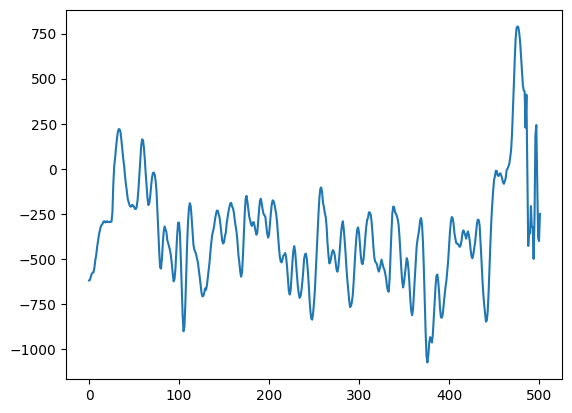

In [169]:
plt.plot(residual_resta)

In [71]:
residual_division=Vel_Pozo_5['ACOUSTIC_INTERVAL_VEL']/muestra_campo_vel['ACOUSTIC_INTERVAL_VEL']

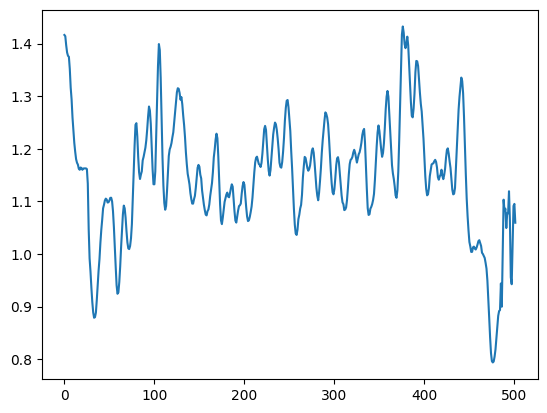

In [72]:
plt.plot(residual_division)

In [80]:
residual_division.fillna(1) ### rellenamos los nulos con 1

0      1.416272
1      1.413944
2      1.396646
3      1.382975
4      1.376696
         ...   
605    1.000000
606    1.000000
607    1.000000
608    1.000000
609    1.000000
Name: ACOUSTIC_INTERVAL_VEL, Length: 610, dtype: float64

In [144]:
residual_division.shape[0]

610

In [146]:
campo_vel_original.shape[1]

1110

Vamos a re muestrear todo el campo a 5 m

In [93]:
def vel_inter1(df_vel,df_depth,intervalo):
    new_depth = np.arange(0, df_depth.max(), intervalo)
    new_df_depth = pd.DataFrame({'DEPTH': new_depth})
    new_df_vel= np.interp(new_df_depth, df_depth, df_vel)
    
    return new_df_vel

Vamos a Resamplear el campo a 5mts

In [150]:



filas=residual_division.shape[0]
columnas=campo_vel_original.shape[1]
Campo_resamp5 = np.empty((residual_division.shape[0], 0))

for i in range(columnas-1):  # Iterar sobre las columnas 0 y 1
    
    # Obtener los datos de vel_inter1 y asegurarse de que estén en forma de columna
    temp1 = np.array(vel_inter1(campo_vel_original[f'{i}'], campo_vel['DEPTH'], 5)).reshape(610, 1)
    
    # Concatenar la columna al array 'a'
    Campo_resamp5 = np.hstack((Campo_resamp5, temp1))




In [218]:
Campo_resamp5

array([[1.56901352, 1.55539341, 1.54125388, ..., 1.47414717, 1.47414717,
        1.47414717],
       [1.55376064, 1.54014053, 1.5382548 , ..., 1.47821252, 1.48009824,
        1.47821252],
       [1.54698867, 1.53336856, 1.51960462, ..., 1.48143346, 1.49128213,
        1.48143346],
       ...,
       [4.92003521, 4.92003521, 4.92003521, ..., 4.92003521, 4.92003521,
        4.92003521],
       [4.92003521, 4.92003521, 4.92003521, ..., 4.92003521, 4.92003521,
        4.92003521],
       [4.92003521, 4.92003521, 4.92003521, ..., 4.92003521, 4.92003521,
        4.92003521]])

In [207]:
Campo_resamp5.shape

(610, 1109)

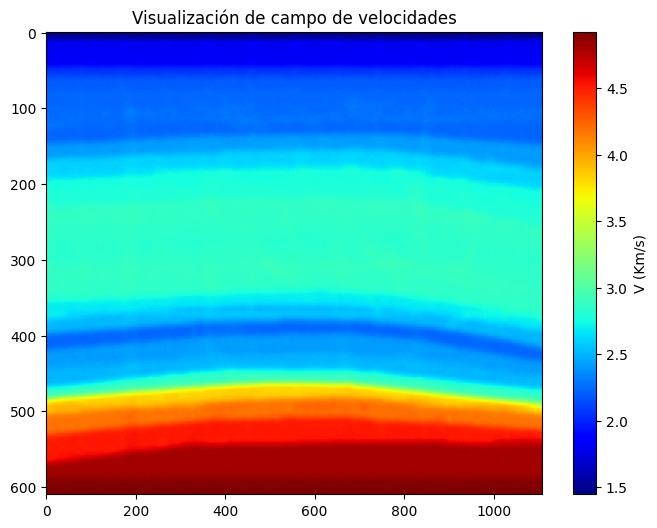

In [208]:


plt.figure(figsize=(8, 6))

# Crear la imagen con el mapa de color 'inferno'
plt.imshow(Campo_resamp5, aspect='auto', cmap='jet', interpolation='nearest')

# Añadir una barra de color
cbar = plt.colorbar()
cbar.set_label('V (Km/s)')

# Añadir título
plt.title('Visualización de campo de velocidades')

# Mostrar el gráfico
plt.show()

Ahora le vamos a multiplicar el residual

In [211]:
residual_division.shape

(610,)

In [212]:
residual_division

0      1.416272
1      1.413944
2      1.396646
3      1.382975
4      1.376696
         ...   
605         NaN
606         NaN
607         NaN
608         NaN
609         NaN
Name: ACOUSTIC_INTERVAL_VEL, Length: 610, dtype: float64

<Axes: >

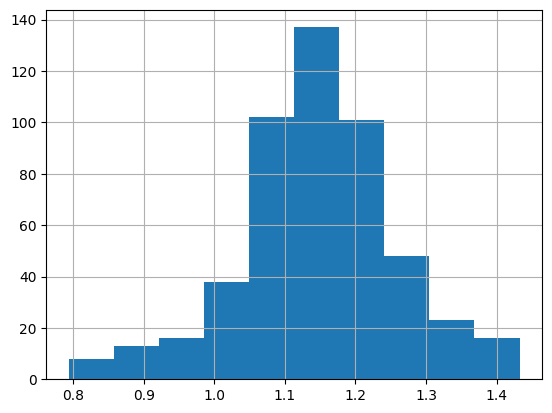

In [178]:
residual_division.hist()

In [179]:

# Convertir residual_division a un array de NumPy
residual_division_np = residual_division.fillna(1).to_numpy()

In [ ]:
df_residual=pd.DataFrame()

In [180]:
residual_division_np

array([1.4162715 , 1.41394442, 1.39664556, 1.38297548, 1.37669616,
       1.37479316, 1.35178662, 1.3161735 , 1.29382768, 1.25972162,
       1.23510593, 1.21115572, 1.19434378, 1.18021447, 1.17345549,
       1.16989315, 1.16209022, 1.16004905, 1.16434574, 1.16327146,
       1.16004905, 1.16241002, 1.16265126, 1.16265126, 1.16265126,
       1.16144945, 1.13358454, 1.04682129, 0.99163751, 0.96656381,
       0.93565018, 0.90879826, 0.88889826, 0.87874756, 0.8798274 ,
       0.88854185, 0.91263968, 0.94107437, 0.96855338, 0.99055628,
       1.02114455, 1.04576133, 1.06506719, 1.08680073, 1.09357773,
       1.10171826, 1.10514716, 1.10348694, 1.09775657, 1.09828961,
       1.10146865, 1.10663844, 1.10686884, 1.09994389, 1.08124857,
       1.05118204, 1.01250803, 0.97594598, 0.94056084, 0.92430192,
       0.92702209, 0.94675923, 0.97636979, 1.01281832, 1.04348484,
       1.07530437, 1.09196758, 1.08662875, 1.06898578, 1.04346778,
       1.02201394, 1.01053344, 1.00928702, 1.01508368, 1.02969

In [213]:




# Multiplicar cada columna de Campo_resamp5 por residual_division
Campo_residual = Campo_resamp5 * residual_division_np[:, np.newaxis]

print(Campo_residual.shape)  # Debería ser (610, 1109)


(610, 1109)


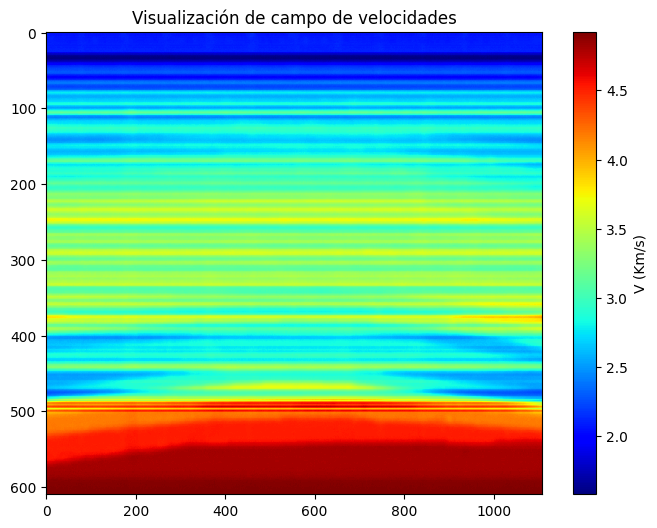

In [214]:
plt.figure(figsize=(8, 6))

# Crear la imagen con el mapa de color 'inferno'
plt.imshow(Campo_residual, aspect='auto', cmap='jet', interpolation='nearest')

# Añadir una barra de color
cbar = plt.colorbar()
cbar.set_label('V (Km/s)')

# Añadir título
plt.title('Visualización de campo de velocidades')

# Mostrar el gráfico
plt.show()

In [226]:

# Convertir residual_division a un array de NumPy
residual_resta_np = residual_resta.fillna(0).to_numpy()

# Multiplicar cada columna de Campo_resamp5 por residual_division
Campo_residual_resta = Campo_resamp5 - residual_resta_np[:, np.newaxis]

print(Campo_residual_resta.shape)  # Debería ser (610, 1109)

(610, 1109)


<Axes: >

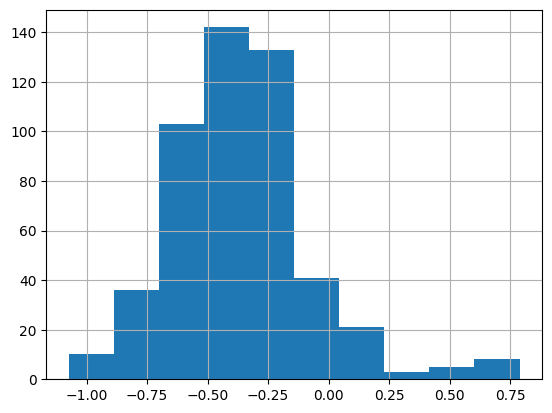

In [227]:
residual_resta.hist()

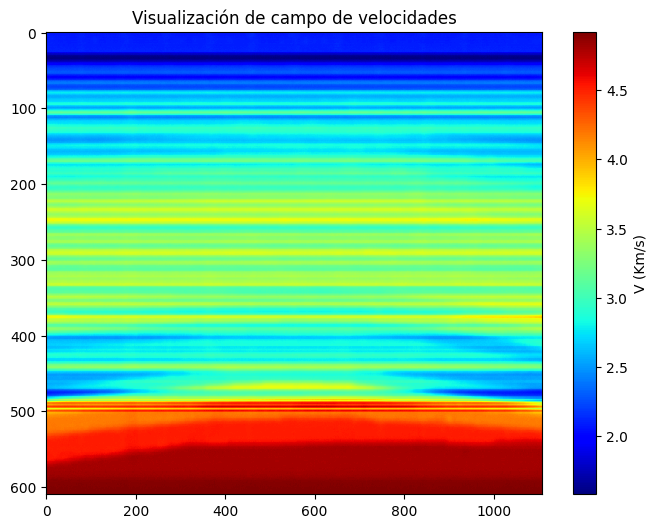

In [228]:
plt.figure(figsize=(8, 6))

# Crear la imagen con el mapa de color 'inferno'
plt.imshow(Campo_residual_resta, aspect='auto', cmap='jet', interpolation='nearest')

# Añadir una barra de color
cbar = plt.colorbar()
cbar.set_label('V (Km/s)')

# Añadir título
plt.title('Visualización de campo de velocidades')

# Mostrar el gráfico
plt.show()